# 04. Random Forest (Non-Linear Model)

As defined in Section B.2 of the proposal, we use Random Forest as a strong non-linear baseline.
Bagging-based ensembles are robust to noise and require little tuning compared to individual trees.

**Key Requirements (per proposal):**
- Evaluate Random Forest Regressor.
- Use 5-fold Cross-Validation.
- Compare against the linear baseline.


## 1. Setup

In [76]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
N_SPLITS = 5

OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('Outputs dir:', OUT_DIR.resolve())

Outputs dir: /Users/bashkal/Desktop/Comp468-ML_in_Python/ali/ML-Final/outputs


## 2. Load Engineered Features

In [77]:
# Section IV.C: Load Development set and Local Test set separately
try:
    train_df      = pd.read_parquet(OUT_DIR / 'train_local.parquet')
    test_local_df = pd.read_parquet(OUT_DIR / 'test_local.parquet')
    kaggle_test_df = pd.read_parquet(OUT_DIR / 'test_features.parquet')
    print('Loaded split parquet samples from', OUT_DIR.resolve())
except Exception as e:
    print('Parquet failed, trying CSV:', e)
    train_df      = pd.read_csv(OUT_DIR / 'train_local.csv')
    test_local_df = pd.read_csv(OUT_DIR / 'test_local.csv')
    kaggle_test_df = pd.read_csv(OUT_DIR / 'test_features.csv')
    print('Loaded CSV split samples from', OUT_DIR.resolve())

print(f'Shapes: train_local {train_df.shape} | test_local {test_local_df.shape} | kaggle_test {kaggle_test_df.shape}')
train_df.head()


Loaded split parquet samples from /Users/bashkal/Desktop/Comp468-ML_in_Python/ali/ML-Final/outputs
Shapes: train_local (19497, 151) | test_local (4875, 151) | kaggle_test (24318, 150)


,PropertyID,NumReserveDays2016Q3,PropertyType,ListingType,Zipcode,Neighborhood,MetropolitanStatisticalArea,NumberofReviews,OverallRating,Bedrooms,Bathrooms,MaxGuests,ResponseRate,ResponseTimemin,Superhost,CancellationPolicy,SecurityDeposit,CleaningFee,ExtraPeopleFee,PublishedNightlyRate,PublishedMonthlyRate,PublishedWeeklyRate,MinimumStay,NumberofPhotos,BusinessReady,InstantbookEnabled,Latitude,Longitude,PropertyAgeDays,ReviewsPerMonth,PricePerGuest,WeeklyDiscount,MonthlyDiscount,BedBathRatio,ResponseRate_missing,ResponseTimemin_missing,SecurityDeposit_missing,CleaningFee_missing,ExtraPeopleFee_missing,OverallRating_missing,...,q1_wd_booked,q1_wd_price_mean,q1_we_booking_rate,q1_wd_booking_rate,q1_weekend_premium,q1_weekend_minus_weekday_book_rate,q2_we_days,q2_we_booked,q2_we_price_mean,q2_wd_days,q2_wd_booked,q2_wd_price_mean,q2_we_booking_rate,q2_wd_booking_rate,q2_weekend_premium,q2_weekend_minus_weekday_book_rate,q1_booked_m1,q1_booked_m2,q1_booked_m3,q2_booked_m4,q2_booked_m5,q2_booked_m6,q1_status_changes,q1_new_bookings,q1_booking_ends,q2_status_changes,q2_new_bookings,q2_booking_ends,h1_status_changes,h1_new_bookings,h1_booking_ends,recent_days,recent_booked,recent_available,recent_price_mean,recent_price_std,recent_booking_rate,recent_available_rate,price_change_q2_q1,booking_rate_change_q2_q1
0,10897656,0,Apartment,Private room,10018,Hell's Kitchen,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",0.0,NaN,1.0,1.0,2,93.0,207.47,0.0,Flexible,NaN,60.0,NaN,235,4900.0,1225.0,4,4.0,0.0,0.0,40.756152,-73.994263,156,0.000000,117.50,0.255319,0.304965,1.000000,0,0,1,0,1,1,...,3,97.368423,0.250000,0.157895,1.001351,0.092105,39,0,100.000000,52,0,100.000000,0.000000,0.000000,1.000000,0.000000,0,0,6,0,0,0,3,1,1,4,0,0,8,1,1,30.0,0.0,15.0,100.000000,0.000000,0.000000,0.500000,0.026490,-0.193548
1,7800905,0,Apartment,Private room,11211,Williamsburg,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",8.0,5.0,1.0,1.0,2,100.0,53.58,0.0,Strict,350.0,50.0,NaN,166,2100.0,545.0,2,12.0,0.0,0.0,40.710032,-73.960971,329,0.729483,83.00,0.530981,0.578313,1.000000,0,0,0,0,1,0,...,0,123.307693,0.000000,0.000000,0.819921,0.000000,27,0,98.666664,34,0,116.000000,0.000000,0.000000,0.850575,0.000000,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.048012,0.000000
2,10838516,37,House,Entire home/apt,11385,Ridgewood,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",0.0,NaN,1.0,1.5,2,NaN,NaN,NaN,Moderate,NaN,NaN,NaN,54,378.0,1512.0,1,16.0,1.0,0.0,40.700399,-73.897498,159,0.000000,27.00,-3.000000,0.766667,0.666667,1,1,1,1,1,1,...,20,54.000000,0.384615,0.384615,1.000000,0.000000,39,14,54.230770,52,16,54.326923,0.358974,0.307692,0.998230,0.051282,6,29,0,30,0,0,3,1,0,4,0,0,8,2,0,30.0,0.0,11.0,54.866665,1.357821,0.000000,0.366667,0.005291,-0.054945
3,6693888,0,Apartment,Entire home/apt,10016,Kips Bay,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",11.0,4.5,1.0,1.0,4,NaN,NaN,0.0,Flexible,500.0,50.0,NaN,175,3650.0,1300.0,3,18.0,1.0,0.0,40.742288,-73.979566,394,0.837563,43.75,-0.061224,0.304762,1.000000,1,1,0,0,1,0,...,11,172.211533,0.076923,0.211538,1.016192,-0.134615,39,7,178.333328,52,10,175.000000,0.179487,0.192308,1.019048,-0.012821,3,11,0,0,1,16,8,1,0,19,1,1,27,2,1,30.0,16.0,10.0,176.333328,2.248882,0.533333,0.333333,0.017427,0.032967
4,10149699,0,Apartment,Private room,11238,Bedford-Stuyvesant,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",1.0,5.0,1.0,1.0,2,NaN,NaN,NaN,Flexible,NaN,NaN,NaN,69,1932.0,483.0,1,5.0,0.0,0.0,40.681119,-73.956469,191,0.157068,34.50,0.000000,0.066667,1.000000,1,1,1,1,1,0,...,0,69.000000,0.000000,0.000000,1.022297,0.000000,39,0,69.000000,52,0,69.000000,0.000000,0.000000,1.000000,0.000000,0,0,0,0,0,0,4,0,0,0,0,0,4,0,0,30.0,0.0,30.0,69.000000,0.000000,0.000000,1.000000,-0.009465,0.000000


In [78]:

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [79]:
TARGET   = 'NumReserveDays2016Q3'
ID_COL   = 'PropertyID'
DROP_COLS = [ID_COL, TARGET]

y = train_df[TARGET].astype(float).values
X = train_df.drop(columns=DROP_COLS)
X_kaggle_test = kaggle_test_df.drop(columns=[ID_COL])
kaggle_test_ids = kaggle_test_df[ID_COL].values

# Align columns (test should have identical columns to train X)
missing_in_test = [c for c in X.columns if c not in X_kaggle_test.columns]
extra_in_test   = [c for c in X_kaggle_test.columns if c not in X.columns]
print('Missing in kaggle test:', missing_in_test)
print('Extra   in kaggle test:', extra_in_test)
X_kaggle_test = X_kaggle_test.reindex(columns=X.columns)
print('After align — X:', X.shape, '| X_kaggle_test:', X_kaggle_test.shape)


Missing in kaggle test: []
Extra   in kaggle test: []
After align — X: (19497, 149) | X_kaggle_test: (24318, 149)


In [80]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# Cap very-high-cardinality categoricals (e.g., Zipcode, Neighborhood) by
# keeping only the top-K most-frequent values for OneHot; rare values become 'Other'.
TOPK = 30
for c in cat_cols:
    top_values = X[c].value_counts(dropna=False).head(TOPK).index
    X[c]             = X[c].where(X[c].isin(top_values), other='Other')
    X_kaggle_test[c] = X_kaggle_test[c].where(X_kaggle_test[c].isin(top_values), other='Other')

print(f'Numeric cols    : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)}')
print('Categorical examples:', cat_cols[:10])


Numeric cols    : 143
Categorical cols: 6
Categorical examples: ['PropertyType', 'ListingType', 'Neighborhood', 'MetropolitanStatisticalArea', 'CancellationPolicy', 'geo_cluster']


## 3. Preprocessing `ColumnTransformer`
- **Numerics:** median imputation. Tree-based models don't need scaling.
- **Categoricals:** fill `NaN` with `'missing'`, then OneHotEncode (`handle_unknown='ignore'`).
- The whole thing lives in a Pipeline so that imputation is fit only on training folds (no leakage).

In [81]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('Preprocessor ready.')

Preprocessor ready.


## 4. 5-Fold CV Evaluation

Helper that runs one model through CV and returns OOF predictions + mean MSE.

In [82]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []

def evaluate_model(name, model, X, y, kf=kf):
    pipe = Pipeline(steps=[
        ('prep',  preprocessor),
        ('model', model),
    ])
    t0 = time.time()
    fold_mses = []
    fold_maes = []
    fold_r2s  = []
    oof = np.zeros(len(y))
    
    for fold, (tr, va) in enumerate(kf.split(X)):
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[va])
        pred = np.clip(pred, 0, 92)   # target is bounded in [0, 92]
        oof[va] = pred
        
        mse = mean_squared_error(y[va], pred)
        mae = mean_absolute_error(y[va], pred)
        r2  = r2_score(y[va], pred)
        
        fold_mses.append(mse)
        fold_maes.append(mae)
        fold_r2s.append(r2)
        print(f'  fold {fold+1}: MSE = {mse:.3f} | MAE = {mae:.3f} | R2 = {r2:.3f}')
        
    elapsed = time.time() - t0
    mean_mse = float(np.mean(fold_mses))
    std_mse  = float(np.std(fold_mses))
    mean_mae = float(np.mean(fold_maes))
    mean_r2  = float(np.mean(fold_r2s))
    
    print(f'\n{name:>22s} | MSE = {mean_mse:7.3f} (±{std_mse:.3f}) | MAE = {mean_mae:7.3f} | R2 = {mean_r2:7.3f} | {elapsed:5.1f}s')
    np.save(OUT_DIR / f'oof_{name}.npy', oof)
    
    return {'name': name, 'mse_mean': mean_mse, 'mse_std': std_mse, 'mae_mean': mean_mae, 'r2_mean': mean_r2,
            'seconds': elapsed, 'oof': oof}

In [83]:
# Load Linear Regression baseline from disk (computed in notebook 03)
# This avoids recomputing the baseline in every notebook.
try:
    baseline_results = pd.read_csv(OUT_DIR / 'baseline_cv_results.csv')
    lr_row = baseline_results[baseline_results['name'] == 'LinearRegression'].iloc[0].to_dict()
    lr_row['oof'] = np.load(OUT_DIR / 'oof_LinearRegression.npy')
    results.append(lr_row)
    print(f"Loaded LinearRegression baseline: MSE = {lr_row['mse_mean']:.3f} (±{lr_row['mse_std']:.3f})")
except Exception as e:
    print(f"Could not load baseline from disk. Have you run notebook 03? Error: {e}")
    # Fallback to recomputing if not found
    # lr_model = LinearRegression()
    # results.append(evaluate_model('LinearRegression', lr_model, X, y))

Loaded LinearRegression baseline: MSE = 207.611 (±5.671)


### 4.1 RandomForestRegressor (Section IV.B.2)
The first non-linear baseline. RF is robust to outliers and requires minimal hyperparameter tuning.
As specified in Section IV.C, we use `RandomizedSearchCV` with a budget of 30-50 iterations.


In [84]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_leaf': randint(2, 10),
    'model__max_features': ['sqrt', 'log2', None]
}

pipe_rf = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

search_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=30, # Section IV.C requirement
    cv=KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest Tuning (RandomizedSearchCV)...")
t0 = time.time()
search_rf.fit(X, y)
print(f"RF Tuning done in {(time.time()-t0)/60:.1f} min")
print("Best Parameters:", search_rf.best_params_)
print("Best CV MSE:", -search_rf.best_score_)

# Use the best model for the results
rf_model = search_rf.best_estimator_['model']
results.append(evaluate_model('RandomForest', rf_model, X, y))


Starting Random Forest Tuning (RandomizedSearchCV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

RF Tuning done in 42.3 min
Best Parameters: {'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 363}
Best CV MSE: 193.5384507515235
  fold 1: MSE = 194.970 | MAE = 8.460 | R2 = 0.737
  fold 2: MSE = 185.325 | MAE = 8.431 | R2 = 0.761
  fold 3: MSE = 186.387 | MAE = 8.351 | R2 = 0.759
  fold 4: MSE = 200.270 | MAE = 8.734 | R2 = 0.743
  fold 5: MSE = 200.740 | MAE = 8.717 | R2 = 0.747

          RandomForest | MSE = 193.538 (±6.600) | MAE =   8.539 | R2 =   0.749 | 554.8s


## 5. Results Summary

In [85]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'oof'} for r in results])
results_df = results_df.sort_values('mse_mean').reset_index(drop=True)
results_df.to_csv(OUT_DIR / 'baseline_cv_results.csv', index=False)
print('CV results (sorted by MSE):')
results_df

CV results (sorted by MSE):


,name,mse_mean,mse_std,mae_mean,r2_mean,seconds
0,RandomForest,193.538451,6.600396,8.538618,0.749400,554.827824
1,LinearRegression,207.611313,5.670924,9.222140,0.731218,8.487963


In [86]:
# Simple mean-blend of the three OOFs — sanity check on whether averaging helps
oof_matrix = np.column_stack([r['oof'] for r in results])
oof_blend = np.clip(oof_matrix.mean(axis=1), 0, 92)
blend_mse = mean_squared_error(y, oof_blend)
print(f'Mean-of-models blend OOF MSE = {blend_mse:.3f}')

Mean-of-models blend OOF MSE = 191.593


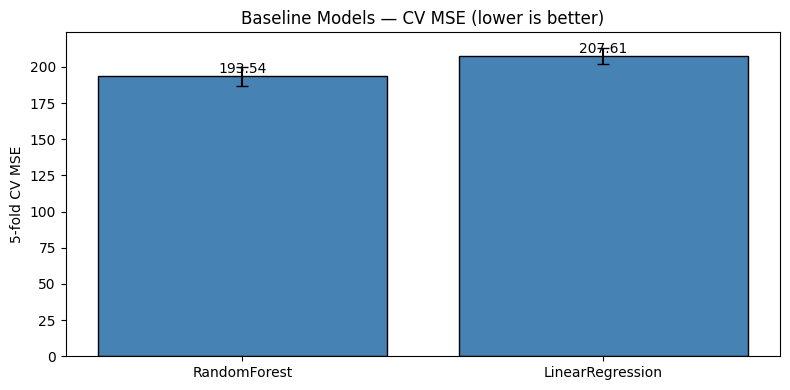

In [87]:
# Quick bar plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['name'], results_df['mse_mean'],
       yerr=results_df['mse_std'], capsize=4, color='steelblue', edgecolor='black')
ax.set_ylabel('5-fold CV MSE')
ax.set_title('Baseline Models — CV MSE (lower is better)')
for i, v in enumerate(results_df['mse_mean']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_cv_bar.png', dpi=120); plt.show()

## 6. Refit Best Model on Full Train → Kaggle Submission

In [91]:
best_name = results_df.iloc[0]['name']

# Robust model lookup
models_dict = {}
if 'rf_model' in globals(): models_dict['RandomForest'] = rf_model
if 'lr_model' in globals(): models_dict['LinearRegression'] = lr_model

# Handle the case where best_name isn't in models_dict
if best_name not in models_dict:
    # If LinearRegression is best but lr_model wasn't defined here locally
    if best_name == 'LinearRegression':
        from sklearn.linear_model import LinearRegression
        models_dict['LinearRegression'] = LinearRegression()
    else:
        backup_best = [n for n in results_df['name'] if n in models_dict][0]
        print(f"Warning: {best_name} is best but not a refittable model here. Using {backup_best}.")
        best_name = backup_best

best_model_obj = models_dict[best_name]
print(f'Best model for submission: {best_name} (CV MSE = {results_df.iloc[0]["mse_mean"]:.3f})')

best_pipe = Pipeline(steps=[('prep', preprocessor), ('model', best_model_obj)])
best_pipe.fit(X, y)
test_pred = np.clip(best_pipe.predict(X_kaggle_test), 0, 92)
print('Kaggle test predictions shape:', test_pred.shape)
print('First 10 preds:', test_pred[:10].round(2))


Best model for submission: RandomForest (CV MSE = 193.538)
Kaggle test predictions shape: (24318,)
First 10 preds: [ 2.25 49.57  7.51 32.69 24.79  4.49  7.3  84.94 72.62 30.09]


## 7. Section IV.C — Unbiased Local Test Evaluation & Feature Importance
We evaluate the best Random Forest on the 20% local test set reserved in notebook 02.
We also compute Permutation Importance to verify model drivers.

--- Unbiased Local Test Results (Random Forest) ---
Local Test MSE: 190.496
Local Test MAE: 8.517
Local Test R2 : 0.750

Saved local test predictions to ../outputs/test_local_pred_RandomForest.npy

Computing Permutation Importance on Local Test Set...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

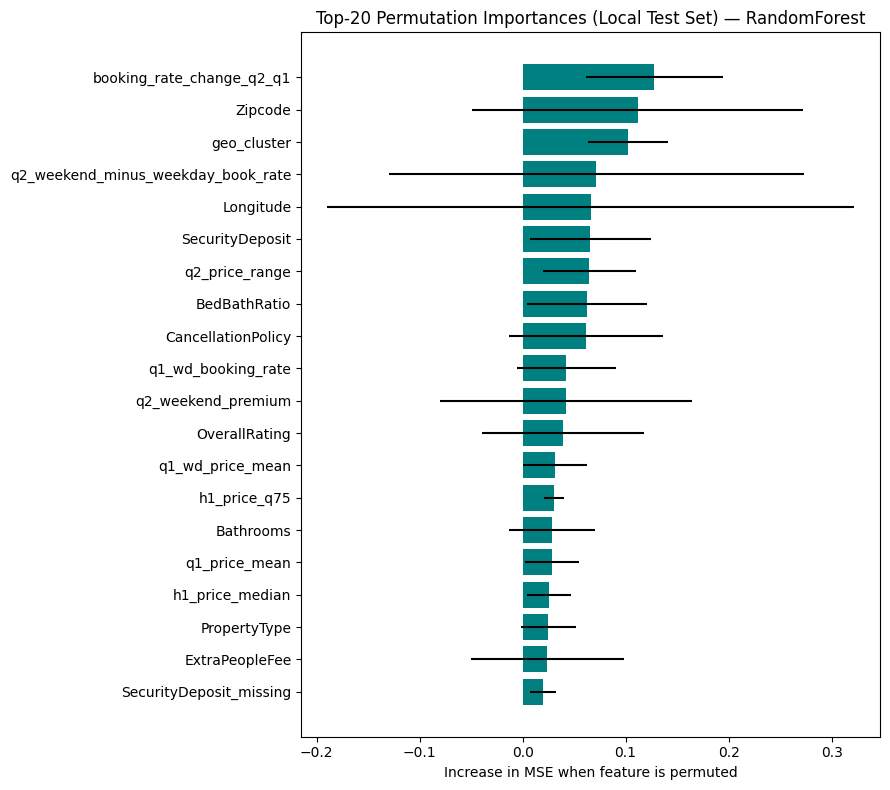

,feature,importance,std
148,booking_rate_change_q2_q1,0.127874,0.066666
2,Zipcode,0.111674,0.160302
47,geo_cluster,0.102302,0.038989
124,q2_weekend_minus_weekday_book_rate,0.071551,0.201316
25,Longitude,0.065970,0.255433
14,SecurityDeposit,0.065832,0.059118
83,q2_price_range,0.064898,0.045184
31,BedBathRatio,0.062853,0.058287
13,CancellationPolicy,0.061563,0.075134
112,q1_wd_booking_rate,0.042623,0.047725


In [92]:
# 1. Prepare Local Test Data
X_test_local = test_local_df.drop(columns=DROP_COLS)
y_test_local = test_local_df[TARGET].astype(float).values

# Section IV.C: Align Categories for Local Test
# Crucial: test_local must use the same category mapping (top-K) as training.
for c in cat_cols:
    top_values = train_df[c].value_counts(dropna=False).head(TOPK).index
    X_test_local[c] = X_test_local[c].where(X_test_local[c].isin(top_values), other='Other')

# Align columns
X_test_local = X_test_local.reindex(columns=X.columns, fill_value=0)

# 2. Predict & Evaluate
# We use the best_pipe which was refit on the full development set (X, y) in the previous cell.
y_test_pred_rf = np.clip(best_pipe.predict(X_test_local), 0, 92)

test_mse_rf = mean_squared_error(y_test_local, y_test_pred_rf)
test_mae_rf = mean_absolute_error(y_test_local, y_test_pred_rf)
test_r2_rf  = r2_score(y_test_local, y_test_pred_rf)

print(f"--- Unbiased Local Test Results (Random Forest) ---")
print(f"Local Test MSE: {test_mse_rf:.3f}")
print(f"Local Test MAE: {test_mae_rf:.3f}")
print(f"Local Test R2 : {test_r2_rf:.3f}")

# 3. Save for Blender (Section 07)
np.save(OUT_DIR / 'test_local_pred_RandomForest.npy', y_test_pred_rf)
print(f"\nSaved local test predictions to {OUT_DIR / 'test_local_pred_RandomForest.npy'}")

# 4. Permutation Importance
print("\nComputing Permutation Importance on Local Test Set...")
perm = permutation_importance(best_pipe, X_test_local, y_test_local,
                              n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE,
                              scoring='neg_mean_squared_error')

imp = pd.DataFrame({
    'feature': X.columns,
    'importance': -perm.importances_mean, # convert back to positive MSE gain
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

# Plot top 20
top = imp.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top['feature'], top['importance'], xerr=top['std'], color='teal')
ax.set_title(f'Top-20 Permutation Importances (Local Test Set) — {best_name}')
ax.set_xlabel('Increase in MSE when feature is permuted')
plt.tight_layout()
plt.show()

imp.head(10)
